In [1]:
# import libraries
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Define Dataset Paths

In [2]:
# Dataset Paths

train_dir = "../data/train"
val_dir = "../data/val"
test_dir = "../data/test"

### Define Image Parameters

In [3]:
# Image Parameters

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 20

### Data Augmentation

In [4]:
# Data Augmentation

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.2,

    horizontal_flip=True,

    brightness_range=[0.8, 1.2],

    fill_mode="nearest"
)

### Validation / Test Generator

In [5]:
# Test Generator

val_test_datagen = ImageDataGenerator(

    rescale=1./255
)

### Create Train Data Loader

In [6]:
# code

train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical"
)

Found 1862 images belonging to 2 classes.


### Create Validation Loader

In [7]:
# code

val_generator = val_test_datagen.flow_from_directory(

    val_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical"
)

Found 399 images belonging to 2 classes.


### Create Test Loader

In [8]:
# code

test_generator = val_test_datagen.flow_from_directory(

    test_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

Found 401 images belonging to 2 classes.


### Verify Class Mapping

In [9]:
# code

print(train_generator.class_indices)

{'bird': 0, 'drone': 1}


### Inspect One Batch

In [10]:
images, labels = next(train_generator)

print(images.shape)

print(labels.shape)

(32, 224, 224, 3)
(32, 2)


### Visualize Augmented Images

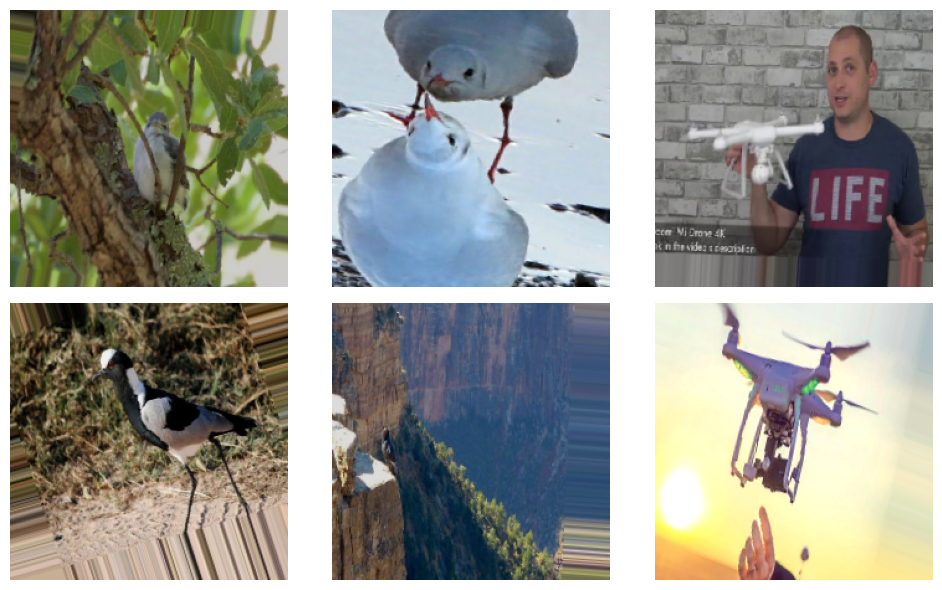

In [11]:
# code

import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(10, 6))

for i in range(6):

    plt.subplot(2, 3, i + 1)

    plt.imshow(images[i])

    plt.axis("off")

plt.tight_layout()

plt.show()